# Low-Rank Optimal Transport through Factor Relaxation with Latent : A tutorial

### Introduction
This work was realised in the context of the ENSAE course "Optimal Transport: from theory to tweaks", under the supervision of M. Cuturi. This notebook aims to reproduce the algorithm introduced in <u>Low-Rank Optimal Transport through Factor Relaxation with Latent Coupling</u> (P.Halmos & al., 2024) and apply it to beginer-friendly toy example. We boast a very hand-on practical approach, as the theory behind this algorithm is already explained in details in the source article.

## Imports

Most of the code here is supported by the libraries jax.numpy and ott, which provide fast computation methods to manipulate gradients and solve optimal transport problems.

In [5]:
import numpy as np
import jax
import jax.numpy as jnp
import ott
from ott.geometry import geometry, pointcloud
from ott.solvers import linear
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

We generate here a random key, that we will split at convenience whenever we need to sample from any distribution.

In [6]:
key = jax.random.key(0)

## Definition of functions

The first (and arguably the most important) function that we introduce is the classic sinkhorn solver. Indeed, the algorithm presented here (henceforth FRLC) is still classified as a sinkhorn method. We will rely on the classic solver provided by the ott librairy in one of its most basic form.

In [7]:
def sinkhorn(K,a,b):
    geom = geometry.Geometry(kernel_matrix=K)
    solver = linear.sinkhorn.Sinkhorn()
    ot_problem = ott.problems.linear.linear_problem.LinearProblem(geom, a, b)
    solved = solver(ot_prob=ot_problem)
    return solved.matrix

The "latent" part in the name of this algorithm comes from the use of a "Latent coupling matrix" T. This matrix is used in computations to allow us to consider independant inner marginals Q and R. We will thus first solve them separately, and then find the best T than links them, to finally use all 3 and compute a transport map.<br>
To update our matrix for Q and R, we use the semi-relaxed projection algorithm underneath:

In [8]:
def SR_proj(K, gamma, tau, a, b, delta, r, n, max_iter = 500):
    u = jnp.ones((n))
    v = jnp.ones((r))
    G = 0
    iter = 0
    while G<delta and iter<3:
        iter+=1
        u_k = u
        v_k = v
        u = a/(K@v)
        v = (b/(jnp.transpose(K)@u))**(tau/(tau +1/gamma))
        G = max(jnp.linalg.norm(jnp.log(u_k/u)), jnp.linalg.norm(jnp.log(v_k/v)))/gamma
    return jnp.diag(u)@K@jnp.diag(v)

We now need a function to initialize all the quantities of interest in the computation of our transport map. This function allows us to generate relevant random sub-couplings Q and R and then the latent coupling matrix T from which we can compute a transport map P. To do that we employ the inner marginals (gQ and gR) initialised as <b>1</b>(r)/r, and ensure that we respect the dual constrains specified by the outer marginals a and b.

In [9]:
def init(a, b, gQ, gR):
    keys = jax.random.split(key, 3)
    n = len(a)
    m = len(b)
    r = len(gQ)
    CQ = jax.random.uniform(keys[0], (n,r))
    CR = jax.random.uniform(keys[1], (m,r))
    CT = jax.random.uniform(keys[2], (r,r))
    KQ = jnp.exp(CQ)
    KR = jnp.exp(CR)
    KT = jnp.exp(CT)
    Q = sinkhorn(KQ, a, gQ) 
    R = sinkhorn(KR, b, gR)
    T = sinkhorn(KT, jnp.transpose(Q)@jnp.ones((n)), jnp.transpose(R)@jnp.ones((m)))
    return Q, R, T

Now we have all the blocks needed for our FRLC algorithm:<br>
-We nitiate our values for P, Q and T<br>
-We use the semi-relaxed projection to update P and Q<br>
-We apply our sinkhorn solver to get the corresponding value for T<br>
We can then compute P, and check if we converged, otherwise we loop again.

In [10]:
def Balanced_FRLC(C, #cost function
                  r, #dimension of the problem
                  a, #first set of constrains
                  b, #second set of constrains
                  tau, #scale used in the semi-relaxed projection, works only in relation with gamma
                  gamma, #scale helping to control the speed of convergence 
                  delta, #threshold for the semi-relaxed projections
                  eps, #threshold under which we considered that the algorithm converged
                  max_iter=100):
    #INITIALISATION
    n, m = jnp.shape(C)
    gQ = (1/r)*jnp.ones(r)
    gR = (1/r)*jnp.ones(r)
    Q, R, T = init(a, b, gQ, gR)
    X = jnp.diag(1/(jnp.transpose(Q)@jnp.ones((n))))@T@jnp.diag(1/(jnp.transpose(R)@jnp.ones((m))))
    Delta = float('inf')
    res = []
    iter=0

    #LOOP
    while Delta > eps and iter<max_iter:
        iter+=1

        #Updating subcouplings P & Q
        GradQ = C@R@jnp.transpose(X) - jnp.outer(jnp.ones((n,1)),jnp.diag(jnp.transpose(C@R@jnp.transpose(X))@Q@jnp.diag(1/gQ)))
        GradR = jnp.transpose(C)@Q@X - jnp.ones((m,1))@jnp.reshape(jnp.diag(jnp.diag(1/gR)@jnp.transpose(R)@jnp.transpose(C)@Q@X), (1,r))
        gamma_k = gamma/max(jnp.linalg.norm(GradQ, ord=1), jnp.linalg.norm(GradR, ord=1))
        KQ = Q*jnp.exp(-gamma_k*GradQ)
        KR = R*jnp.exp(-gamma_k*GradR)
        Q_new = SR_proj(KQ, gamma_k, tau, a, jnp.transpose(Q)@jnp.ones((n)), delta, r, n) #New values for Q & R
        R_new = SR_proj(KR, gamma_k, tau, b, jnp.transpose(R)@jnp.ones((m)), delta, r, m)
        gQ = jnp.transpose(Q_new)@jnp.ones((n)) #Compute the new inner marginals
        gR = jnp.transpose(R_new)@jnp.ones((m))

        #Updating Latent coupling matrix T
        GradT = jnp.diag(1/gQ)@jnp.transpose(Q_new)@C@R_new@jnp.diag(1/gR)
        gamma_t = gamma/jnp.linalg.norm(GradT, ord=1)
        KT = T*jnp.exp(-gamma_t*GradT)
        T_new = sinkhorn(KT, gQ, gR) #New value of T from the inner marginals
        
        #Check if we converged
        Delta = (1/gamma_k**2) * (jnp.linalg.norm(Q_new - Q) + jnp.linalg.norm(R_new - R) + jnp.linalg.norm(T_new - T)) 
        
        #Assign new values and compute the corresponding transport map
        X = jnp.diag(1/gQ)@T@jnp.diag(1/gR)
        Q = Q_new
        R = R_new
        T = T_new
        P = Q@X@jnp.transpose(R)
        res.append(P)
    return res


## Experiment

We start with one of the most basic toy exemple, by generating a dataset with points sampled from a normal distribution as a starting point, and points sampled from a uniform distribution as a target. The associated constraints are also uniformely sampled, and the cost matrix is computed with the Euclidean distance.

In [11]:

def generate_points(n, m, r, key):
    keys = jax.random.split(key, 4)
    x = jax.random.normal(keys[0], (n,r)) + 1
    y = jax.random.uniform(keys[1], (m,r))

    a = jax.random.uniform(keys[2], (jnp.shape(x)[0]))
    b = jax.random.uniform(keys[3], (jnp.shape(y)[0]))
    a = a/jnp.sum(a)
    b = b/jnp.sum(b)

    C = pointcloud.PointCloud(x,y).cost_matrix

    return x, y, a, b, C

In [12]:
n = 25
m = 50
r = 2
x, y, a, b, C = generate_points(n, m, r, jax.random.key(1))

As we still are in two dimensions, we can plot those points onto a grid to have an idea of what we're dealing with:

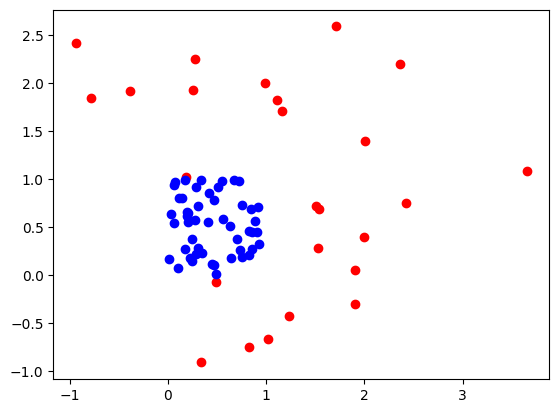

In [13]:
plt.scatter(x[:,0], x[:,1], color='red')
plt.scatter(y[:,0], y[:,1], color='blue')
plt.show()

We then introduce the parameters for the different thresholds and scales used in the algorithm. Those parameters are extremely use-case dependent, and thus have been chosen after trial and errors. One is welcome to try and play with them, as it helps to gain a better feeling of their respective effect.

In [14]:
gamma = 25
delta = 1e-4
tau = 10
eps = 1e-4

Now that we have everything that we need, it's finally time to run our algorithm!

In [15]:
P = Balanced_FRLC(C, r, a, b, tau, gamma, delta, eps)

The output keeps the transport map generated at each iteration, and thus we can look at the associated costs.

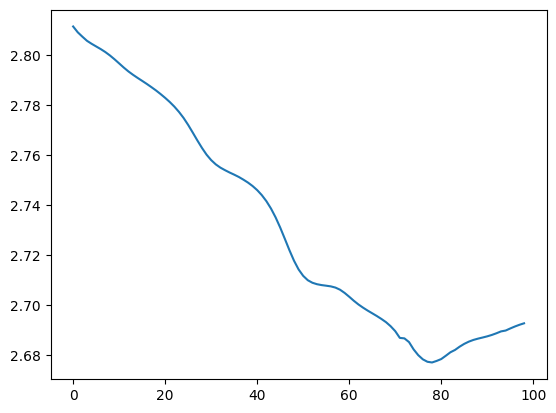

In [16]:
cost = []
for p in P:
    cost.append(jnp.sum(jnp.multiply(C,p)))
cost = cost[1:]
plt.plot(cost)
plt.show()

We still want to be sure that we are close to the constrains we defined. Our final transport map should abide by: <br>
P·<b>1</b>m = a <br>
<b>1</b>n·P = b <br>
We thus check the distance (in norm 1) between those vectors:

In [17]:
Last_P = P[-1]
print('||a - P*1(m)||_1 :' )
print(jnp.sum(jnp.abs(a - Last_P@jnp.ones(m))))

||a - P*1(m)||_1 :
5.0172675e-05


In [18]:
print('||b - 1(n)*P||_1 :' )
print(jnp.sum(jnp.abs(b - jnp.ones(n)@Last_P)))

||b - 1(n)*P||_1 :
0.031632546


Now that we know that we have an appropriate transport map, we can plot it:

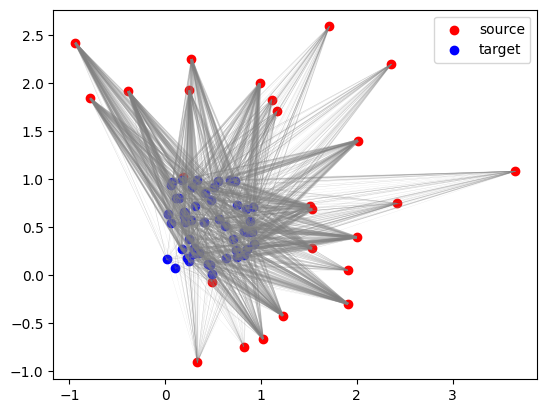

In [ ]:
fig, ax = plt.subplots()

lines = []
width = []
n_inf = jnp.max(jnp.abs(Last_P))
for i in range(jnp.shape(Last_P)[0]):
    for j in range(jnp.shape(Last_P)[1]):
        if Last_P[i,j]> n_inf*0.001: #we only keep the most probable edges
            lines.append([x[i], y[j]])
            width.append(Last_P[i,j]*500) #the more probable an edge is, the wider it will be

ax.scatter(x[:,0], x[:,1], color='red', label='source')
ax.scatter(y[:,0], y[:,1], color='blue', label='target')
lc = LineCollection(lines, linewidth=np.clip(width, 0.1, 2), color='gray', alpha=0.4)
ax.add_collection(lc)
ax.legend()
ax.set_aspect("equal")
plt.show()

#### Comparison
But how do we fare against other methods? Just like in the article, we will try ourself on the lowrank-sinkhorn algorithm. We will not explain in detail how it works, since it is not the topic of this tutorial. One can find more information on [the corresponding tutorial](https://ott-jax.readthedocs.io/tutorials/linear/300_LRSinkhorn.html).<br>

In [26]:
def LR_Sinkhorn(a,
                b,
                x,
                y,
                eps):
    geom = pointcloud.PointCloud(x,y, epsilon=eps)
    ot_prob = ott.problems.linear.linear_problem.LinearProblem(geom, a, b)
    solver = linear.sinkhorn_lr.LRSinkhorn(rank=r)
    ot_lr = solver(ot_prob)
    return ot_lr

Now we will generate simple dataset in the same way as before, but this time with increasingly higher ranks, and compare the performances of the computed maps over them.

In [27]:
#Recall all parameters
n = 25
m = 50
gamma = 25
delta = 1e-4
tau = 10
eps = 1e-4

cost_FRLC = []
cost_ot_lr = []
#Loop over ranks
for r in range(2,20):
    x, y, a, b, C = generate_points(n, m, r, jax.random.key(r))
    P_FRLC = Balanced_FRLC(C, r, a, b, tau, gamma, delta, eps)[-1]
    cost_FRLC.append(jnp.sum(C*P_FRLC))
    ot_lr = LR_Sinkhorn(a,b, x, y, eps)
    cost_ot_lr.append(ot_lr.reg_ot_cost)

We can plot those curves, and see how they perform against each other.

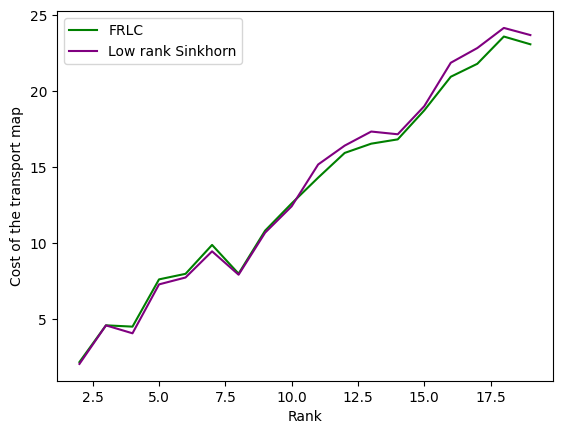

In [28]:
plt.plot(range(2,20), cost_FRLC, color='green', label='FRLC')
plt.plot(range(2,20), cost_ot_lr, color='purple', label='Low rank Sinkhorn')
plt.legend()
plt.ylabel('Cost of the transport map')
plt.xlabel('Rank')
plt.show()

We can see that those two methods seem very close in performances with the parameters that we set.